In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [3]:
df = pd.read_csv(url)

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace = True)

/tmp/ipykernel_2308/2042018206.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace = True)


In [10]:
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace = True)

/tmp/ipykernel_2308/2751139379.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(embarked_mode, inplace = True)


In [11]:
df.drop(columns = ['Cabin'], inplace = True)

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (14, 10))


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

/tmp/ipykernel_2308/3683942257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', palette='Set2')


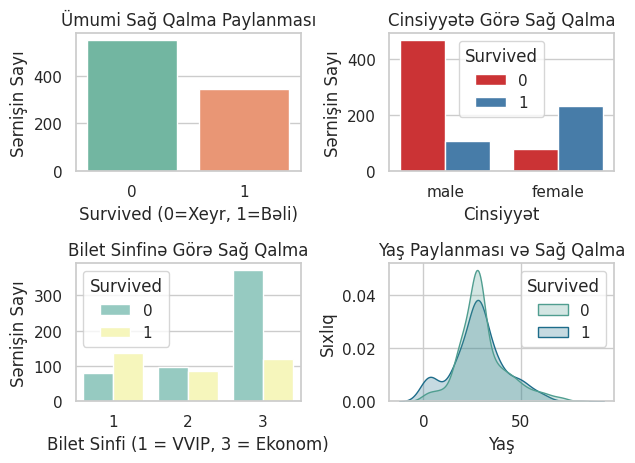

In [14]:
# 1. Neçə nəfər sağ qaldı? (0 = Həlak oldu, 1 = Sağ qaldı)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Survived', palette='Set2')
plt.title('Ümumi Sağ Qalma Paylanması')
plt.xlabel('Survived (0=Xeyr, 1=Bəli)')
plt.ylabel('Sərnişin Sayı')

# 2. Cinsiyyətə görə Sağ Qalma
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set1')
plt.title('Cinsiyyətə Görə Sağ Qalma')
plt.xlabel('Cinsiyyət')
plt.ylabel('Sərnişin Sayı')

# 3. Bilet Sinfinə (Pclass) görə Sağ Qalma
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set3')
plt.title('Bilet Sinfinə Görə Sağ Qalma')
plt.xlabel('Bilet Sinfi (1 = VVIP, 3 = Ekonom)')
plt.ylabel('Sərnişin Sayı')

# 4. Yaşın Sağ Qalmağa Təsiri (KDE plot)
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False, palette='crest')
plt.title('Yaş Paylanması və Sağ Qalma')
plt.xlabel('Yaş')
plt.ylabel('Sıxlıq')

plt.tight_layout()
plt.show()

In [15]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [16]:
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})

In [17]:
df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True)

In [18]:
df_model = df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch'])

In [19]:
df_model.head()

,Survived,Pclass,Sex,Age,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,7.2500,2,False,True
1,1,1,1,38.0,71.2833,2,False,False
2,1,3,1,26.0,7.9250,1,False,True
3,1,1,1,35.0,53.1000,2,False,True
4,0,3,0,35.0,8.0500,1,False,True


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
X = df_model.drop(columns = ['Survived'])
y = df_model['Survived']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [23]:
log_reg = LogisticRegression(max_iter = 500)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

In [24]:
rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [25]:
print(f"Logistic Regression Accuracy: {acc_log * 100:.2f}%")
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%\n")
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 80.45%
Random Forest Accuracy: 81.56%

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [26]:
importances = rf_clf.feature_importances_
feature_names = X.columns

In [27]:
feature_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp = feature_imp.sort_values(by = 'Importance', ascending = False)

/tmp/ipykernel_2308/3645777467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = feature_imp, x = 'Importance', y = 'Feature', palette = 'viridis')


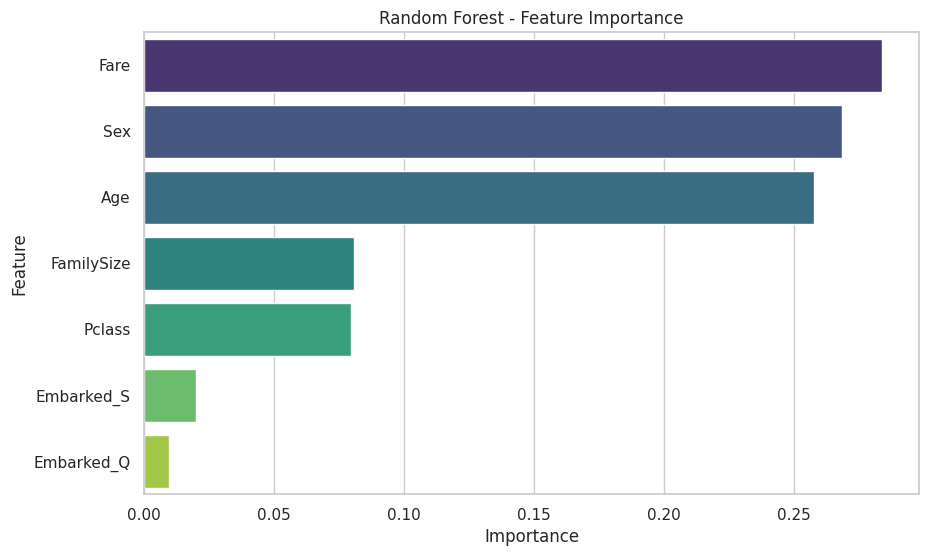

In [28]:
plt.figure(figsize = (10, 6))
sns.barplot(data = feature_imp, x = 'Importance', y = 'Feature', palette = 'viridis')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [29]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [30]:
xgb_model = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42,
    eval_metrics = 'logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [18:28:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
lgb_model = LGBMClassifier(
    n_estimators = 100,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42,
    verbose = -1
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

In [32]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy (%)': [acc_log * 100, acc_rf * 100, acc_xgb * 100, acc_lgb * 100]
}).sort_values(by = 'Accuracy (%)', ascending = False)

print("Modellerin muqayise cedveli: ")
print(comparison_df.to_string(index = False))

Modellerin muqayise cedveli: 
              Model  Accuracy (%)
      Random Forest     81.564246
            XGBoost     81.564246
           LightGBM     81.005587
Logistic Regression     80.446927


In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [35]:
grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_grid = param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1
)

In [37]:
print("GridSearchCV icra olunur, zehmet olmasa gozleyin...")
grid_search.fit(X_train, y_train)

GridSearchCV icra olunur, zehmet olmasa gozleyin...


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [38]:
print("En yaxsi parametrler")
print(grid_search.best_params_)

En yaxsi parametrler
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [39]:
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

In [40]:
print(f"Tenzimlenmis modelin deqiqliyi (Tuned Accuracy): {acc_tuned * 100:.2f}%")

Tenzimlenmis modelin deqiqliyi (Tuned Accuracy): 80.45%


In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# Sequential Neural Network Modelinin Qurulması
nn_model = Sequential([
    Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)),
    Dropout(0.2),  # Overfitting-in qarşısını almaq üçün
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'sigmoid')  # Binary Classification üçün Sigmoid istifadə edirik
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
nn_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [45]:
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 0   # Ekranda 100 sətir çap olub yeri tutmasın deyə
)

In [46]:
loss, acc_nn = nn_model.evaluate(X_test_scaled, y_test, verbose = 0)
print(f"Deep Learning (Keras Neural Network) Accuracy: {acc_nn * 100:.2f}%")

Deep Learning (Keras Neural Network) Accuracy: 83.24%


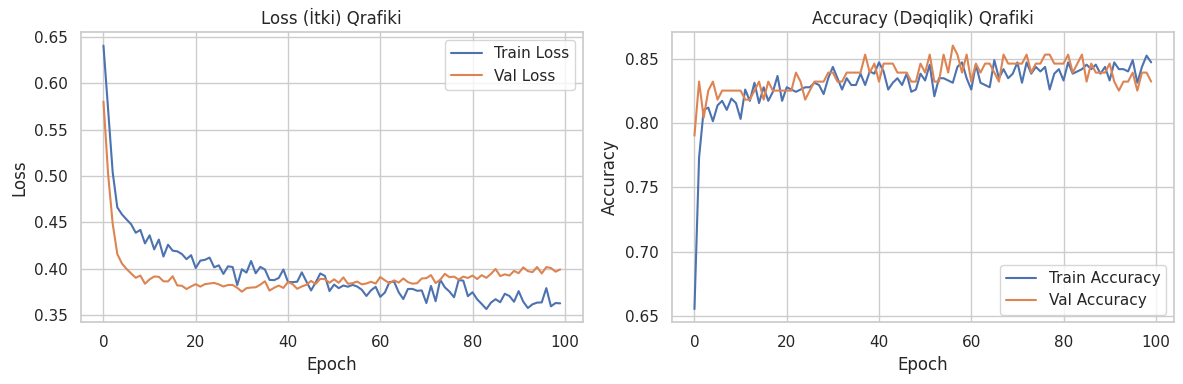

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (İtki) Qrafiki')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy (Dəqiqlik) Qrafiki')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [57]:
import pickle

# Modeli fayl kimi saxlayırıq
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(rf_clf, f)

print("Model uğurla yaddaşa yazıldı!")

Model uğurla yaddaşa yazıldı!


In [58]:
# !pip install -q streamlit
# !npm install localtunnel

In [59]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

st.set_page_config(page_title="Titanic Təxmini", page_icon="🚢")
st.title("🚢 Titanic Sağ Qalma Təxmini")

@st.cache_resource
def load_model():
    with open('titanic_model.pkl', 'rb') as f:
        return pickle.load(f)

model = load_model()

st.sidebar.header("Sərnişin Məlumatları")
pclass = st.sidebar.selectbox("Bilet Sinfi", [1, 2, 3], index=2)
sex = st.sidebar.radio("Cinsiyyət", ["Qadın", "Kişi"])
age = st.sidebar.slider("Yaş", 1, 80, 28)
fare = st.sidebar.slider("Bilet Qiyməti ($)", 0.0, 500.0, 32.0)
family_size = st.sidebar.slider("Ailə Sayı", 1, 10, 1)
embarked = st.sidebar.selectbox("Liman", ["Cherbourg (C)", "Queenstown (Q)", "Southampton (S)"])

sex_val = 1 if sex == "Qadın" else 0
embarked_Q = 1 if "Q" in embarked else 0
embarked_S = 1 if "S" in embarked else 0

input_data = np.array([[pclass, sex_val, age, fare, family_size, embarked_Q, embarked_S]])

if st.button("Təxmin Et 🔮"):
    prediction = model.predict(input_data)[0]
    proba = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        st.success(f"🎉 **Sağ Qaldı!** (Ehtimal: {proba*100:.1f}%)")
    else:
        st.error(f"☠️ **Həlak Oldu.** (Sağ qalma ehtimalı: {proba*100:.1f}%)")


Overwriting app.py


In [60]:
from google.colab import output

!streamlit run app.py &> /dev/null &
output.serve_kernel_port_as_iframe(8501, height='650')

<IPython.core.display.Javascript object>

In [61]:
# Colab IP ünvanını öyrənirik (Localtunnel şifrəsi kimi lazımdır)
!curl ipv4.icanhazip.com

# Streamlit-i arxa fonda başladırıq
!streamlit run app.py &> /dev/null & npx localtunnel --port 8501

34.143.221.132
⠙your url is: https://tame-cougars-smash.loca.lt
^C


In [56]:
# Test datası üzərində modelin səhvlərini çıxarırıq
results_df = X_test.copy()
results_df['Real_Survived'] = y_test
results_df['Predicted'] = y_pred_rf

# Səhv olunan sətirlər (Real cavab ilə Təxmin üst-üstə düşməyənlər)
errors = results_df[results_df['Real_Survived'] != results_df['Predicted']]

print(f"--- SƏHV ANALİZİ İCMALI ---")
print(f"Ümumi Test Sayı: {len(y_test)}")
print(f"Səhv Təxmin Sayı: {len(errors)}")
print(f"Dəqiqlik: {((len(y_test) - len(errors)) / len(y_test)) * 100:.2f}%\n")

# Səhvlərin Növləri:
# False Positive (FP): Əslində həlak olub (0), amma model sağ qaldı (1) deyib
fp = errors[(errors['Real_Survived'] == 0) & (errors['Predicted'] == 1)]

# False Negative (FN): Əslində sağ qalıb (1), amma model həlak oldu (0) deyib
fn = errors[(errors['Real_Survived'] == 1) & (errors['Predicted'] == 0)]

print(f"False Positives (Model 'Sağ qaldı' dedi, amma öldü): {len(fp)}")
print(f"False Negatives (Model 'Həlak oldu' dedi, amma sağ qaldı): {len(fn)}\n")

print("--- Modelin Səhv Etidiyi İlk 5 Sərnişinin Profil ---")
print(errors[['Sex', 'Pclass', 'Age', 'Fare', 'Real_Survived', 'Predicted']].head())

--- SƏHV ANALİZİ İCMALI ---
Ümumi Test Sayı: 179
Səhv Təxmin Sayı: 33
Dəqiqlik: 81.56%

False Positives (Model 'Sağ qaldı' dedi, amma öldü): 15
False Negatives (Model 'Həlak oldu' dedi, amma sağ qaldı): 18

--- Modelin Səhv Etidiyi İlk 5 Sərnişinin Profil ---
     Sex  Pclass   Age     Fare  Real_Survived  Predicted
709    0       3  28.0  15.2458              1          0
39     1       3  14.0  11.2417              1          0
621    0       1  42.0  52.5542              1          0
192    1       3  19.0   7.8542              1          0
673    0       2  31.0  13.0000              1          0
